In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
sns.set(style="whitegrid", palette="pastel", font_scale=1)
plt.rcParams["figure.figsize"] = (5,3)

In [4]:
bank = pd.read_excel("Bank_updated.xlsx")

In [5]:
bank.sample(5)

,Client_ID,Status_of_existing_checking_account,Duration_in_month,Credit_history,Purpose,Credit_amount,Savings_account_bonds,Present_employment_since,Installment_rate_percent_income,gender,marital status,Other_debtors_guarantors,Present_residence_since,Property,Age_in_years,Other_installment_plans,Housing,Number_of_existing_credits_at_this_bank,Job Category,Income Level,Annual Income (PKR),Number_of_people_liable_for_maintenance,Credit_Risk
119,C00120,"5,000 – 49,999",31,all credits at this bank paid back duly,Credit Card,17698000,"< 10,000",4 <= ... < 7 years,3,Male,Married,none,1,Property Mortgage,40,bank,rent,4,Skilled worker,High Income,7260565,1,GOOD
3427,C03428,"5,000 – 49,999",39,critical account/other credits existing (not a...,Credit Card,8044000,"100,000 – 999,999",unemployed,1,Female,Divorced,co-applicant,3,Property Mortgage,46,none,own,4,Business persons,High Income,16498158,2,BAD
7433,C07434,"≥ 500,000",24,delay in paying off in the past,Housing Loan,14594000,"< 10,000",1 <= ... < 4 years,3,Male,Married,guarantor,2,financial collateral,56,bank,own,1,Skilled worker,High Income,7264041,2,BAD
4679,C04680,"50,000 – 499,999",7,delay in paying off in the past,Auto Loan,15720000,no saving account,>= 7 years,3,Male,Married,guarantor,4,security deposit,50,stores,own,3,Others (daily wagers/unemployed),Low Income,35997,1,BAD
1194,C01195,"5,000 – 49,999",20,all credits at this bank paid back duly,Housing Loan,10326000,"≥ 1,000,000",1 <= ... < 4 years,4,Female,Divorced,co-applicant,1,financial collateral,24,stores,own,3,Skilled worker,Low Income,757749,2,GOOD


# Exploratory Data Analysis

In [7]:
df = bank.copy()

In [11]:
df.describe()

,Duration_in_month,Credit_amount,Installment_rate_percent_income,Present_residence_since,Age_in_years,Number_of_existing_credits_at_this_bank,Annual Income (PKR),Number_of_people_liable_for_maintenance
count,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000
mean,38.114300,1.017048e+07,2.505500,2.498400,46.779900,2.506500,5.844892e+06,1.495300
std,19.942758,5.655361e+06,1.118524,1.124599,16.682173,1.115743,5.236164e+06,0.500003
min,4.000000,2.500000e+05,1.000000,1.000000,18.000000,1.000000,2.945600e+04,1.000000
25%,21.000000,5.322500e+06,2.000000,1.000000,32.000000,2.000000,7.742022e+05,1.000000
50%,38.000000,1.021750e+07,3.000000,2.000000,47.000000,3.000000,6.103417e+06,1.000000
75%,56.000000,1.501625e+07,4.000000,4.000000,61.000000,4.000000,8.158132e+06,2.000000
max,72.000000,2.000000e+07,4.000000,4.000000,75.000000,4.000000,1.649816e+07,2.000000


1. #### Duration_in_month (Represents: Length of the loan in months)
| Statistic                    | Meaning                                                                            |
| ---------------------------- | ---------------------------------------------------------------------------------- |
| **count = 10000**            | All 10,000 records have valid duration values.                                     |
| **mean = 38.11 months**      | Average loan duration is around 3.2 years.                                         |
| **std = 19.94**              | Very high spread — durations vary widely.                                          |
| **min = 4 months**           | Shortest loan is 4 months.                                                         |
| **25% = 21 months**          | 25% of loans are less than 21 months.                                              |
| **50% (median) = 38 months** | Half the loans are shorter than 38 months — same as mean → symmetric distribution. |
| **75% = 56 months**          | 25% are longer than 56 months.                                                     |
| **max = 72 months**          | Longest loan is 6 years.                                                           |
#### Interpretation: Loan durations vary widely. No severe outliers. MST distribution looks moderately spread from 1–6 years.

<Axes: xlabel='Duration_in_month', ylabel='Count'>

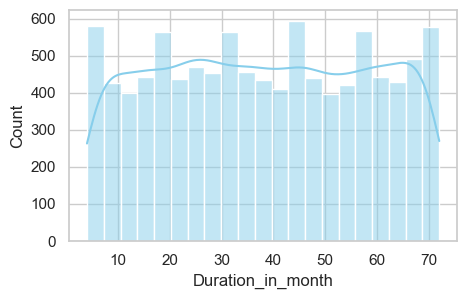

In [13]:
sns.histplot(data=df, x="Duration_in_month", kde=True, color="skyblue")

#### 2. Credit_amount (Represents: Loan amount taken)
| Statistic                    | Explanation                                          |
| ---------------------------- | ---------------------------------------------------- |
| **mean = 10.17 million PKR** | Average loan size is ~10.17M.                        |
| **std = 5.65M PKR**          | Huge variation — plenty of small and very big loans. |
| **min = 0.25M**              | Smallest loan is 250,000 PKR.                        |
| **25% = 5.32M**              | Lower 25% loans are small to medium.                 |
| **50% = 10.21M**             | Typical (median) loan is ~10M PKR.                   |
| **75% = 15.01M**             | Top 25% loans are larger than 15M PKR.               |
| **max = 20M**                | Biggest loan is 20,000,000 PKR.                      |
#### Interpretation: Very large spread → income and credit scoring models must normalize this. Distribution probably right-skewed (few very large loans).

<Axes: xlabel='Credit_amount', ylabel='Count'>

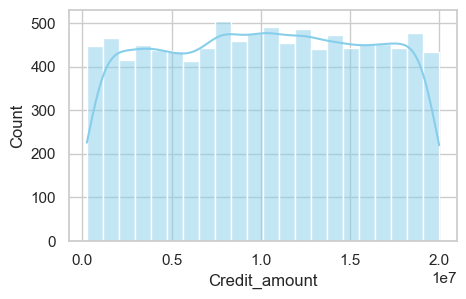

In [15]:
sns.histplot(data=df, x="Credit_amount", kde=True, color="skyblue")

#### 3. Installment_rate_percent_income (Represents what % of the borrower’s income is paid monthly as loan installment)
| Statistic         | Explanation                                     |
| ----------------- | ----------------------------------------------- |
| **mean = 2.505%** | Average person pays ~2.5% of income each month. |
| **std = 1.11**    | Some pay only 1%, others up to 4%.              |
| **min = 1%**      | Lowest installment burden.                      |
| **25% = 2%**      | Most people pay at least 2%.                    |
| **50% = 3%**      | Typical rate is 3%.                             |
| **75% = 4%**      | 25% pay the maximum allowed rate.               |
| **max = 4%**      | Dataset caps at 4%.                             |
#### Interpretation: This column is categorical-discrete (1,2,3,4). Higher values mean higher burden → more risk in credit scoring.

<Axes: xlabel='Installment_rate_percent_income', ylabel='Count'>

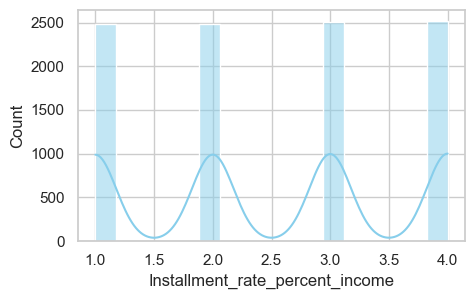

In [17]:
sns.histplot(data=df, x="Installment_rate_percent_income", kde=True, color="skyblue")

#### 4. Present_residence_since (Represents: How long (years) the borrower has lived at current residence)
Values from 1 to 4 → discrete category.
| Statistic             | Explanation                   |
| --------------------- | ----------------------------- |
| **mean = 2.49 years** | Average stay is ~2.5 years.   |
| **std = 1.12**        | Variation is moderate.        |
| **min = 1 year**      | Newly moved.                  |
| **25% = 1 year**      | Many have lived only 1 year.  |
| **50% = 2 years**     | Typical duration is 2.        |
| **75% = 4 years**     | Some are long-term residents. |
| **max = 4 years**     | Maximum category.             |
#### Interpretation: Stability indicator — people staying longer are usually lower risk.

<Axes: xlabel='Present_residence_since', ylabel='Count'>

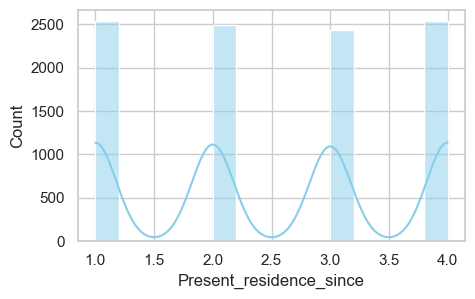

In [21]:
sns.histplot(data=df, x="Present_residence_since", kde=True, color="skyblue")

#### 5. Age_in_years (Represents: Borrower’s current age)
| Statistic              | Explanation                        |
| ---------------------- | ---------------------------------- |
| **mean = 46.78 years** | Average borrower is ~47 years old. |
| **std = 16.68**        | Age varies widely.                 |
| **min = 18**           | Youngest legal adult.              |
| **25% = 32**           | 25% are younger than 32.           |
| **50% = 47**           | Median age is 47.                  |
| **75% = 61**           | 25% are older than 61.             |
| **max = 75**           | Oldest is 75.                      |
#### Interpretation: Widely distributed. May affect risk scoring — very young and very old may carry different risk profiles.

<Axes: xlabel='Age_in_years', ylabel='Count'>

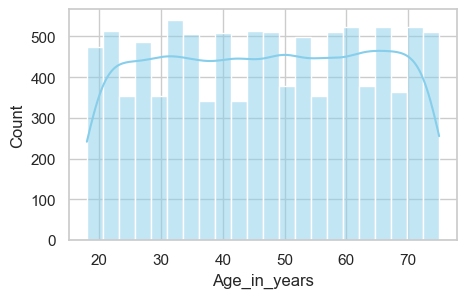

In [26]:
sns.histplot(data=df, x="Age_in_years", kde=True, color="skyblue")

#### 6. Number_of_existing_credits_at_this_bank (Represents: Loans already taken from the same bank)
Values: 1 to 4 (category type, not continuous)
| Statistic        | Explanation                                    |
| ---------------- | ---------------------------------------------- |
| **mean = 2.506** | Most customers have around 2–3 existing loans. |
| **std = 1.11**   | Spread is moderate.                            |
| **min = 1**      | At least 1 loan.                               |
| **25% = 2**      | 25% have 2 loans.                              |
| **50% = 3**      | Typical customer has 3 loans.                  |
| **75% = 4**      | Heavy borrowers.                               |
| **max = 4**      | Maximum category.                              |
#### Interpretation: Higher value → riskier because they already owe a lot

<Axes: xlabel='Number_of_existing_credits_at_this_bank', ylabel='Count'>

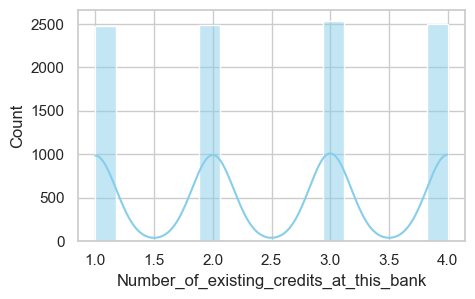

In [32]:
sns.histplot(data=df, x="Number_of_existing_credits_at_this_bank", kde=True, color="skyblue")

#### 7. Annual Income (PKR) (Represents: Borrower’s yearly income)
| Statistic             | Explanation                                                     |
| --------------------- | --------------------------------------------------------------- |
| **mean = 5.84M PKR**  | Average income ~5.8 million per year.                           |
| **std = 5.23M**       | Very high variation — some earn extremely high incomes.         |
| **min = 29,456 PKR**  | Very low salary (likely part-time or incorrect).                |
| **25% = 774,202 PKR** | Lower earners.                                                  |
| **50% = 6.1M PKR**    | Median is high (means some very high incomes pull the average). |
| **75% = 8.15M PKR**   | Top earners.                                                    |
| **max = 16.49M**      | Highest income in dataset.                                      |
#### Interpretation: Income distribution is highly skewed → scaling required. Min value looks suspicious (29k per year = 2,400 per month).

In [35]:
df[df["Annual Income (PKR)"] <= 100000]

,Client_ID,Status_of_existing_checking_account,Duration_in_month,Credit_history,Purpose,Credit_amount,Savings_account_bonds,Present_employment_since,Installment_rate_percent_income,gender,marital status,Other_debtors_guarantors,Present_residence_since,Property,Age_in_years,Other_installment_plans,Housing,Number_of_existing_credits_at_this_bank,Job Category,Income Level,Annual Income (PKR),Number_of_people_liable_for_maintenance,Credit_Risk
17,C00018,"≥ 500,000",66,delay in paying off in the past,Auto Loan,10901000,no saving account,4 <= ... < 7 years,4,Female,Divorced,co-applicant,2,Car,18,none,own,1,Others (daily wagers/unemployed),Low Income,36624,2,BAD
19,C00020,"< 5,000",62,existing credits paid back duly till now,Auto Loan,11952000,"100,000 – 999,999",< 1 year,4,Male,Married,none,3,financial collateral,64,stores,for free,1,Others (daily wagers/unemployed),Low Income,34095,2,BAD
20,C00021,"50,000 – 499,999",38,critical account/other credits existing (not a...,Auto Loan,609000,no saving account,1 <= ... < 4 years,2,Female,Divorced,co-applicant,2,Car,56,none,own,3,Others (daily wagers/unemployed),Low Income,37647,2,GOOD
23,C00024,"< 5,000",24,no credits taken/ all credits paid back duly,Auto Loan,2533000,"10,000 – 99,999",unemployed,3,Male,single,guarantor,1,financial collateral,58,stores,own,3,Others (daily wagers/unemployed),Low Income,33989,2,BAD
25,C00026,"≥ 500,000",36,delay in paying off in the past,Auto Loan,12894000,"100,000 – 999,999",1 <= ... < 4 years,2,Female,Divorced,co-applicant,1,financial collateral,56,bank,for free,3,Others (daily wagers/unemployed),Low Income,38005,2,BAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9961,C09962,"50,000 – 499,999",65,all credits at this bank paid back duly,Auto Loan,898000,"≥ 1,000,000",4 <= ... < 7 years,1,Male,single,co-applicant,4,financial collateral,60,stores,rent,1,Others (daily wagers/unemployed),Low Income,37328,1,BAD
9972,C09973,"≥ 500,000",39,all credits at this bank paid back duly,Auto Loan,6755000,"10,000 – 99,999",< 1 year,3,Female,Divorced,guarantor,4,security deposit,23,none,rent,3,Others (daily wagers/unemployed),Low Income,34665,1,GOOD
9977,C09978,"5,000 – 49,999",27,no credits taken/ all credits paid back duly,Auto Loan,5476000,"10,000 – 99,999",unemployed,1,Female,Separated,guarantor,3,Car,18,stores,own,3,Others (daily wagers/unemployed),Low Income,36805,2,GOOD
9978,C09979,"< 5,000",35,delay in paying off in the past,Auto Loan,5881000,"≥ 1,000,000",>= 7 years,1,Female,Separated,guarantor,3,security deposit,63,stores,for free,2,Others (daily wagers/unemployed),Low Income,37249,1,GOOD


<Axes: xlabel='Annual Income (PKR)', ylabel='Count'>

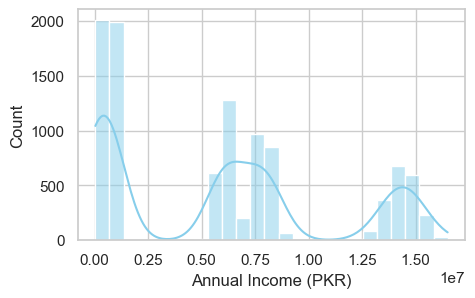

In [37]:
sns.histplot(data=df, x="Annual Income (PKR)", kde=True, color="skyblue")

#### 8. Number_of_people_liable_for_maintenance (Represents: People financially dependent on the borrower)
Values are 1 or 2.
| Statistic        | Explanation                          |
| ---------------- | ------------------------------------ |
| **mean = 1.495** | Most borrowers have ~1–2 dependents. |
| **std = 0.50**   | Expected for binary values.          |
| **min = 1**      | At least 1 dependent.                |
| **25% = 1**      | Lower group.                         |
| **50% = 1**      | Median is 1.                         |
| **75% = 2**      | Top group.                           |
| **max = 2**      | Maximum allowed category.            |
#### Interpretation: Most borrowers support 1 person. Having 2 might increase financial burden.

<Axes: xlabel='Number_of_people_liable_for_maintenance', ylabel='Count'>

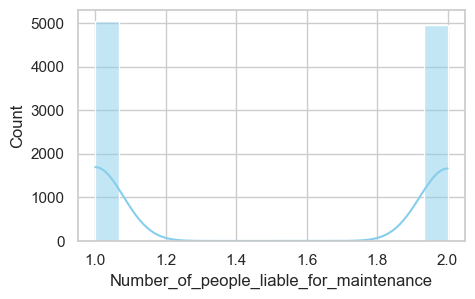

In [40]:
sns.histplot(data=df, x="Number_of_people_liable_for_maintenance", kde=True, color="skyblue")

🎯 Overall Dataset Insights
✔ Highly variable numerical values (Credit amount, Income)

→ Must be normalized for ML models.

✔ Several columns are categorical-discrete (1–4)

→ Should be encoded as categories, not treated as continuous.

✔ No missing values

→ Good for training ML models.

✔ Some columns show skewed distribution

→ May require log transformation (Income, Credit Amount).

In [43]:
target = "Credit_Risk"

<Axes: xlabel='Credit_Risk', ylabel='Duration_in_month'>

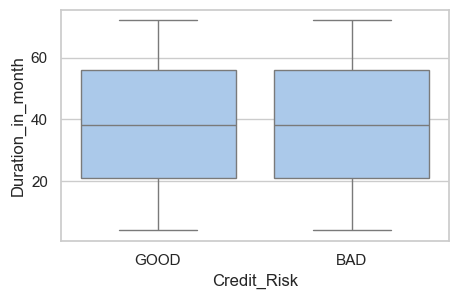

In [45]:
sns.boxplot(data=df, x=target, y="Duration_in_month")

In [47]:
# num_cols = df.select_dtypes(include=np.number).columns
corr = df[['Duration_in_month','Credit_amount', 'Annual Income (PKR)']].corr()
corr

,Duration_in_month,Credit_amount,Annual Income (PKR)
Duration_in_month,1.000000,-0.009667,0.013886
Credit_amount,-0.009667,1.000000,-0.017133
Annual Income (PKR),0.013886,-0.017133,1.000000


In [49]:
df = bank.copy()

In [51]:
X = df.iloc[:,1:22]
y = df.iloc[:,-1]

In [53]:
from sklearn.model_selection import train_test_split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [57]:
print(X_train.shape)
print(X_test.shape)

(8000, 21)
(2000, 21)


In [59]:
df.shape

(10000, 23)

In [61]:
X_train.drop(columns=["Present_employment_since", "Duration_in_month","Annual Income (PKR)", "Job Category"], inplace=True)
X_test.drop(columns=["Present_employment_since", "Duration_in_month","Annual Income (PKR)", "Job Category"], inplace=True)

In [63]:
X_test.shape

(2000, 17)

In [65]:
cat_cols = [
    "Purpose",
    "marital status",
    "gender",
    "Property",
    "Other_installment_plans",
    "Housing",
    "Credit_history",
    "Savings_account_bonds",
    "Other_debtors_guarantors",
    "Status_of_existing_checking_account"
]
cat_col_indexs = [
    X_train.columns.get_loc(col)
    for col in cat_cols
]
cat_col_indexs

[2, 7, 6, 10, 12, 13, 1, 4, 8, 0]

In [67]:
num_cols = [
    "Age_in_years",
    "Credit_amount"
]
num_col_indexs = [
    X_train.columns.get_loc(col)
    for col in num_cols
]
print(num_col_indexs)
print(X_train.columns[num_col_indexs])

[11, 3]
Index(['Age_in_years', 'Credit_amount'], dtype='object')


In [69]:
ordinal_cols = [
    "Income Level",
    "Installment_rate_percent_income",
    "Number_of_existing_credits_at_this_bank",
    "Number_of_people_liable_for_maintenance"   
]
ord_col_indexes = [
    X_train.columns.get_loc(col)
    for col in ordinal_cols
]
ord_col_indexes

[15, 5, 14, 16]

In [71]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.decomposition import PCA

pca = PCA(n_components=10)


# Column index groups
num_col_indexes = [11, 3]
cat_col_indexes = [2, 7, 6, 10, 12, 13, 1, 4, 8, 0]
ord_col_indexes = [15, 5, 14, 16]

# Define preprocessing for each type
preprocessor = ColumnTransformer(
    transformers=[
        # ("pt", PowerTransformer(method="box-cox"), num_col_indexes),
        ("age_scale", StandardScaler(), [11]),
        ("credit_amount_robust", RobustScaler(), [3]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_col_indexes),
        ("ord", OrdinalEncoder(), ord_col_indexes)
    ]
)

# ft = FunctionTransformer(np.log1p)
# month_transformed = ft.transform([4,19])

# Full pipeline

rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=8,
    max_features= 0.6,
    max_samples= 1.0,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42)

lr = LogisticRegression(penalty="l1", C=1.0, solver='liblinear', max_iter=1000, random_state=42)

dt = DecisionTreeClassifier()

svc = SVC()

gb = GradientBoostingClassifier()

knn = KMeans(n_clusters=2)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    # ("scale",SelectKBest(score_func=mutual_info_classif, k=15)),
    ("classifier", lr)
])

le = LabelEncoder()
y_train_transformed = le.fit_transform(y_train)
y_test_transformed = le.transform(y_test)

# Fit the pipeline
pipe.fit(X_train, y_train_transformed)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('age_scale', StandardScaler(),
                                                  [11]),
                                                 ('credit_amount_robust',
                                                  RobustScaler(), [3]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [2, 7, 6, 10, 12, 13, 1, 4, 8,
                                                   0]),
                                                 ('ord', OrdinalEncoder(),
                                                  [15, 5, 14, 16])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

In [72]:
y_pred = pipe.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score
print("Accuracy Score Random Forest Pipe: {}".format(accuracy_score(y_test_transformed, y_pred)))

Accuracy Score Random Forest Pipe: 0.493


In [77]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(pipe, X_train, y_train_transformed, cv=10, scoring="accuracy"))

0.5015000000000001

In [79]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split

df2 = df.copy()
y = df2["Credit_Risk"]
X = df2.drop(["Credit_Risk","Client_ID"], axis=1)

# Identify categorical features
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

model = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    l2_leaf_reg=5,
    random_strength=1.5,
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=50
)

# ✅ Train using Pool (correct)
model.fit(train_pool, eval_set=test_pool)

print("Train Score:", model.score(train_pool))
print("Test Score:", model.score(test_pool))

0:	learn: 0.5090000	test: 0.5115000	best: 0.5115000 (0)	total: 223ms	remaining: 1m 6s
50:	learn: 0.5393750	test: 0.5195000	best: 0.5300000 (42)	total: 1.92s	remaining: 9.39s
100:	learn: 0.5567500	test: 0.5035000	best: 0.5300000 (42)	total: 3.39s	remaining: 6.68s
150:	learn: 0.5625000	test: 0.5095000	best: 0.5300000 (42)	total: 5.04s	remaining: 4.97s
200:	learn: 0.5873750	test: 0.5115000	best: 0.5300000 (42)	total: 6.91s	remaining: 3.4s
250:	learn: 0.6187500	test: 0.5110000	best: 0.5300000 (42)	total: 9.02s	remaining: 1.76s
299:	learn: 0.6383750	test: 0.5160000	best: 0.5300000 (42)	total: 11s	remaining: 0us

bestTest = 0.53
bestIteration = 42

Shrink model to first 43 iterations.
Train Score: 0.519125
Test Score: 0.53


In [81]:
y.value_counts(normalize=True)

Credit_Risk
GOOD    0.5021
BAD     0.4979
Name: proportion, dtype: float64

In [82]:
# # Required Libraries
# import pandas as pd
# import numpy as np
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import StandardScaler, PowerTransformer
# from sklearn.impute import SimpleImputer
# from sklearn.model_selection import train_test_split, GridSearchCV
# from catboost import CatBoostClassifier

# # Example dataset
# # df = pd.read_csv("your_data.csv")
# # target = 'target_column'
# X = df.drop(columns=target)
# y = df[target]

# # Identify categorical and numerical features
# cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
# num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# # Convert numeric categorical features to string
# for col in cat_features:
#     X[col] = X[col].astype(str)

# # Numeric pipeline: impute missing + optional power transform + scaling
# num_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')),
#     ('power', PowerTransformer(method='yeo-johnson', standardize=True))
# ])

# # Categorical pipeline: impute missing + convert to string
# cat_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='most_frequent'))
# ])

# # Full preprocessing
# preprocessor = ColumnTransformer([
#     ('num', num_pipeline, num_features),
#     ('cat', cat_pipeline, cat_features)
# ])

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() < 10 else None
# )

# # Preprocess training data
# X_train_proc = preprocessor.fit_transform(X_train)
# X_test_proc = preprocessor.transform(X_test)

# # Get indices of categorical features in the preprocessed data
# cat_feature_indices = list(range(len(num_features), X_train_proc.shape[1]))

# # CatBoost classifier
# cat_model = CatBoostClassifier(
#     iterations=2000,
#     learning_rate=0.03,
#     depth=6,
#     eval_metric='AUC',
#     random_seed=42,
#     early_stopping_rounds=50,
#     verbose=100
# )

# # Full pipeline
# pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', cat_model)
# ])

# # Fit the model
# pipeline.named_steps['model'].fit(
#     X_train_proc, 
#     y_train, 
#     cat_features=cat_feature_indices,
#     eval_set=(X_test_proc, y_test)
# )

# # Predictions
# y_pred = pipeline.predict(X_test_proc)
# y_pred_proba = pipeline.predict_proba(X_test_proc)[:,1]

# # Optional: Hyperparameter tuning
# param_grid = {
#     'model__depth': [4, 6, 8],
#     'model__learning_rate': [0.01, 0.03, 0.05],
#     'model__iterations': [500, 1000, 2000]
# }

# grid_search = GridSearchCV(
#     pipeline, param_grid, cv=3, scoring='roc_auc' if y.nunique() < 10 else 'r2', n_jobs=-1
# )
# grid_search.fit(X_train_proc, y_train)

# print("Best parameters:", grid_search.best_params_)
# print("Best CV score:", grid_search.best_score_)

In [83]:
# import pandas as pd
# from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.impute import SimpleImputer
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report, roc_auc_score


# # Load data
# df = pd.read_excel("Bank_updated.xlsx")  # replace with your file
# X = df.drop(columns=["Credit_Risk","Client_ID"])
# y = df["Credit_Risk"]

# # Preprocessing
# numeric_features = X.select_dtypes(include=["int64","float64"]).columns
# categorical_features = X.select_dtypes(include=["object"]).columns

# numeric_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler())
# ])

# categorical_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("encoder", OneHotEncoder(handle_unknown="ignore"))
# ])

# preprocessor = ColumnTransformer([
#     ("num", numeric_pipeline, numeric_features),
#     ("cat", categorical_pipeline, categorical_features)
# ])



# models = {
#     "LogReg": LogisticRegression(max_iter=1000),
#     "RandomForest": RandomForestClassifier(n_estimators=200),
#     "GradientBoosting": GradientBoostingClassifier()
# }



# # Full pipeline
# results = []
# for name, model in models.items():
#     pipe = Pipeline([
#         ("preprocessor", preprocessor),  # same ColumnTransformer
#         ("selector", SelectKBest(mutual_info_classif, k=10)),
#         ("classifier", GradientBoostingClassifier())
#     ])
#     pipe.fit(X_train, y_train)
# y_pred_proba = pipe.predict_proba(X_test)[:,1]
# print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

<Axes: xlabel='Annual Income (PKR)_boxcox', ylabel='Count'>

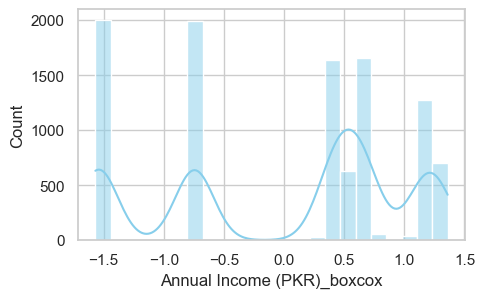

In [91]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method="box-cox")
month_transformed = pt.fit_transform(df[["Annual Income (PKR)"]])
df["Annual Income (PKR)_boxcox"] = month_transformed.flatten()
sns.histplot(data=df, x="Annual Income (PKR)_boxcox", kde=True, color="skyblue")

<Axes: xlabel='Annual Income (PKR)_yeo', ylabel='Count'>

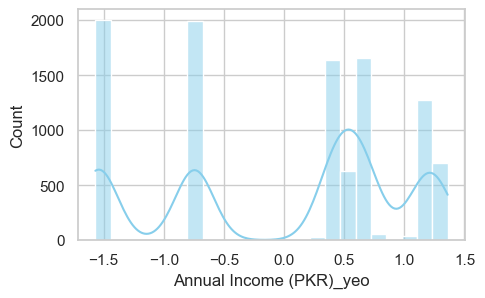

In [92]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
month_transformed = pt.fit_transform(df[["Annual Income (PKR)"]])
df["Annual Income (PKR)_yeo"] = month_transformed.flatten()
sns.histplot(data=df, x="Annual Income (PKR)_yeo", kde=True, color="skyblue")

<Axes: xlabel='Duration_in_month_yeojohnson', ylabel='Count'>

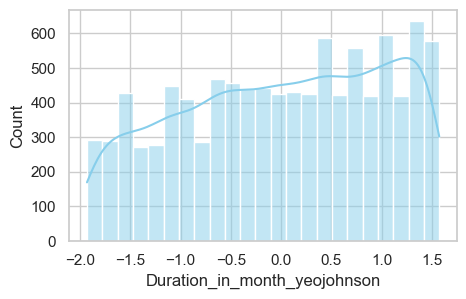

In [93]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
month_transformed = pt.fit_transform(df[["Duration_in_month"]])
df["Duration_in_month_yeojohnson"] = month_transformed.flatten()
sns.histplot(data=df, x="Duration_in_month_yeojohnson", kde=True, color="skyblue")

<Axes: xlabel='Annual Income (PKR)_log', ylabel='Count'>

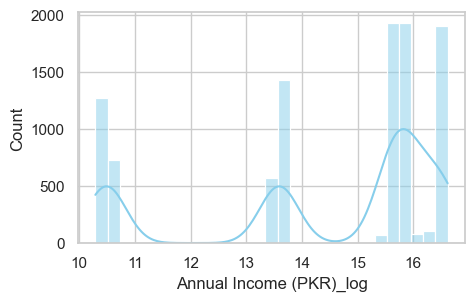

In [94]:
from sklearn.preprocessing import FunctionTransformer
ft = FunctionTransformer(np.log1p)
month_transformed = ft.transform(df[["Annual Income (PKR)"]])
df["Annual Income (PKR)_log"] = month_transformed
sns.histplot(data=df, x="Annual Income (PKR)_log", kde=True, color="skyblue")

In [95]:
df.sample(5)

,Client_ID,Status_of_existing_checking_account,Duration_in_month,Credit_history,Purpose,Credit_amount,Savings_account_bonds,Present_employment_since,Installment_rate_percent_income,gender,marital status,Other_debtors_guarantors,Present_residence_since,Property,Age_in_years,Other_installment_plans,Housing,Number_of_existing_credits_at_this_bank,Job Category,Income Level,Annual Income (PKR),Number_of_people_liable_for_maintenance,Credit_Risk,Annual Income (PKR)_boxcox,Annual Income (PKR)_yeo,Duration_in_month_yeojohnson,Annual Income (PKR)_log
659,C00660,"< 5,000",27,delay in paying off in the past,Personal Loan,9023000,no saving account,< 1 year,1,Male,Married,co-applicant,3,Property Mortgage,38,stores,rent,3,Salaried individuals,High Income,6305781,2,GOOD,0.456231,0.456231,-0.484799,15.656978
6677,C06678,"50,000 – 499,999",26,delay in paying off in the past,Housing Loan,1111000,"< 10,000",unemployed,2,Female,Separated,guarantor,2,Car,24,none,for free,4,Skilled worker,High Income,7382294,2,GOOD,0.585616,0.585616,-0.537866,15.814595
9660,C09661,"≥ 500,000",56,existing credits paid back duly till now,Personal Loan,6995000,"100,000 – 999,999",>= 7 years,1,Female,Separated,co-applicant,2,financial collateral,49,stores,rent,1,Salaried individuals,High Income,5453373,1,GOOD,0.342767,0.342766,0.895709,15.511745
4132,C04133,"50,000 – 499,999",69,no credits taken/ all credits paid back duly,Housing Loan,19943000,"10,000 – 99,999",< 1 year,1,Female,Divorced,none,1,financial collateral,29,none,own,4,Skilled worker,Low Income,742941,1,GOOD,-0.774983,-0.774984,1.448634,13.518373
3918,C03919,"50,000 – 499,999",61,existing credits paid back duly till now,Housing Loan,15929000,"< 10,000",>= 7 years,2,Male,single,none,4,security deposit,43,bank,for free,4,Skilled worker,Low Income,836301,2,BAD,-0.726961,-0.726962,1.111967,13.636745


In [96]:
df[df["Annual Income (PKR)"] <= 29456]

,Client_ID,Status_of_existing_checking_account,Duration_in_month,Credit_history,Purpose,Credit_amount,Savings_account_bonds,Present_employment_since,Installment_rate_percent_income,gender,marital status,Other_debtors_guarantors,Present_residence_since,Property,Age_in_years,Other_installment_plans,Housing,Number_of_existing_credits_at_this_bank,Job Category,Income Level,Annual Income (PKR),Number_of_people_liable_for_maintenance,Credit_Risk,Annual Income (PKR)_boxcox,Annual Income (PKR)_yeo,Duration_in_month_yeojohnson,Annual Income (PKR)_log
9123,C09124,"< 5,000",70,no credits taken/ all credits paid back duly,Auto Loan,11854000,"< 10,000",1 <= ... < 4 years,1,Female,Divorced,none,2,Property Mortgage,47,stores,for free,3,Others (daily wagers/unemployed),Low Income,29456,2,BAD,-1.568804,-1.568802,1.48998,10.290687


In [97]:
df["DTI"] = df["Credit_amount"] / df["Annual Income (PKR)"]

In [98]:
df.sample(5)

,Client_ID,Status_of_existing_checking_account,Duration_in_month,Credit_history,Purpose,Credit_amount,Savings_account_bonds,Present_employment_since,Installment_rate_percent_income,gender,marital status,Other_debtors_guarantors,Present_residence_since,Property,Age_in_years,Other_installment_plans,Housing,Number_of_existing_credits_at_this_bank,Job Category,Income Level,Annual Income (PKR),Number_of_people_liable_for_maintenance,Credit_Risk,Annual Income (PKR)_boxcox,Annual Income (PKR)_yeo,Duration_in_month_yeojohnson,Annual Income (PKR)_log,DTI
7591,C07592,"< 5,000",25,existing credits paid back duly till now,Credit Card,13338000,no saving account,4 <= ... < 7 years,1,Male,single,co-applicant,3,security deposit,36,none,own,1,Business persons,High Income,14895717,1,BAD,1.250066,1.250067,-0.591456,16.516584,0.895425
4734,C04735,"≥ 500,000",55,critical account/other credits existing (not a...,Auto Loan,4084000,"10,000 – 99,999",unemployed,4,Male,single,guarantor,3,Car,67,none,rent,1,Others (daily wagers/unemployed),Low Income,35425,2,BAD,-1.542426,-1.542425,0.851865,10.475201,115.285815
8931,C08932,"< 5,000",7,critical account/other credits existing (not a...,Housing Loan,15670000,"≥ 1,000,000",4 <= ... < 7 years,1,Male,Married,co-applicant,1,security deposit,75,none,for free,2,Skilled worker,High Income,7995705,1,GOOD,0.653723,0.653723,-1.695614,15.894415,1.959802
3455,C03456,"< 5,000",71,all credits at this bank paid back duly,Credit Card,7567000,no saving account,unemployed,4,Female,Divorced,co-applicant,1,security deposit,63,none,for free,4,Business persons,High Income,15411107,2,GOOD,1.286294,1.286295,1.531171,16.550599,0.491010
9643,C09644,"< 5,000",67,existing credits paid back duly till now,Housing Loan,2727000,"10,000 – 99,999",< 1 year,2,Male,single,guarantor,4,financial collateral,38,none,own,3,Skilled worker,High Income,7471437,2,GOOD,0.595744,0.595744,1.365469,15.826598,0.364990


In [99]:
df[df["Annual Income (PKR)"] <= 100000]

,Client_ID,Status_of_existing_checking_account,Duration_in_month,Credit_history,Purpose,Credit_amount,Savings_account_bonds,Present_employment_since,Installment_rate_percent_income,gender,marital status,Other_debtors_guarantors,Present_residence_since,Property,Age_in_years,Other_installment_plans,Housing,Number_of_existing_credits_at_this_bank,Job Category,Income Level,Annual Income (PKR),Number_of_people_liable_for_maintenance,Credit_Risk,Annual Income (PKR)_boxcox,Annual Income (PKR)_yeo,Duration_in_month_yeojohnson,Annual Income (PKR)_log,DTI
17,C00018,"≥ 500,000",66,delay in paying off in the past,Auto Loan,10901000,no saving account,4 <= ... < 7 years,4,Female,Divorced,co-applicant,2,Car,18,none,own,1,Others (daily wagers/unemployed),Low Income,36624,2,BAD,-1.537496,-1.537495,1.323644,10.508486,297.646352
19,C00020,"< 5,000",62,existing credits paid back duly till now,Auto Loan,11952000,"100,000 – 999,999",< 1 year,4,Male,Married,none,3,financial collateral,64,stores,for free,1,Others (daily wagers/unemployed),Low Income,34095,2,BAD,-1.548028,-1.548027,1.154654,10.436935,350.549934
20,C00021,"50,000 – 499,999",38,critical account/other credits existing (not a...,Auto Loan,609000,no saving account,1 <= ... < 4 years,2,Female,Divorced,co-applicant,2,Car,56,none,own,3,Others (daily wagers/unemployed),Low Income,37647,2,GOOD,-1.533375,-1.533374,0.070012,10.536035,16.176588
23,C00024,"< 5,000",24,no credits taken/ all credits paid back duly,Auto Loan,2533000,"10,000 – 99,999",unemployed,3,Male,single,guarantor,1,financial collateral,58,stores,own,3,Others (daily wagers/unemployed),Low Income,33989,2,BAD,-1.548481,-1.548479,-0.645596,10.433822,74.524111
25,C00026,"≥ 500,000",36,delay in paying off in the past,Auto Loan,12894000,"100,000 – 999,999",1 <= ... < 4 years,2,Female,Divorced,co-applicant,1,financial collateral,56,bank,for free,3,Others (daily wagers/unemployed),Low Income,38005,2,BAD,-1.531951,-1.531950,-0.027404,10.545499,339.271149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9961,C09962,"50,000 – 499,999",65,all credits at this bank paid back duly,Auto Loan,898000,"≥ 1,000,000",4 <= ... < 7 years,1,Male,single,co-applicant,4,financial collateral,60,stores,rent,1,Others (daily wagers/unemployed),Low Income,37328,1,BAD,-1.534652,-1.534651,1.281654,10.527526,24.057008
9972,C09973,"≥ 500,000",39,all credits at this bank paid back duly,Auto Loan,6755000,"10,000 – 99,999",< 1 year,3,Female,Divorced,guarantor,4,security deposit,23,none,rent,3,Others (daily wagers/unemployed),Low Income,34665,1,GOOD,-1.545610,-1.545608,0.118221,10.453515,194.865138
9977,C09978,"5,000 – 49,999",27,no credits taken/ all credits paid back duly,Auto Loan,5476000,"10,000 – 99,999",unemployed,1,Female,Separated,guarantor,3,Car,18,stores,own,3,Others (daily wagers/unemployed),Low Income,36805,2,GOOD,-1.536762,-1.536761,-0.484799,10.513416,148.784133
9978,C09979,"< 5,000",35,delay in paying off in the past,Auto Loan,5881000,"≥ 1,000,000",>= 7 years,1,Female,Separated,guarantor,3,security deposit,63,stores,for free,2,Others (daily wagers/unemployed),Low Income,37249,1,GOOD,-1.534970,-1.534969,-0.076633,10.525407,157.883433


<Axes: xlabel='DTI', ylabel='Count'>

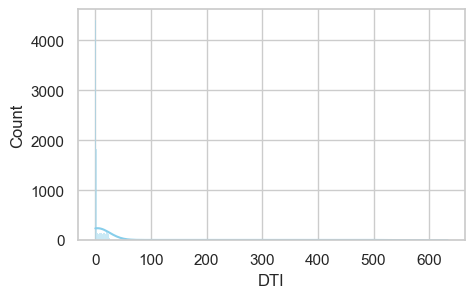

In [100]:
sns.histplot(data=df, x="DTI", kde=True, color="skyblue")

<Axes: xlabel='DTI_log', ylabel='Count'>

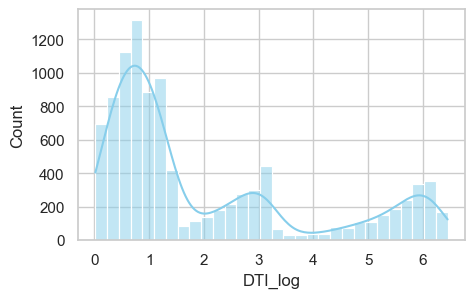

In [101]:
from sklearn.preprocessing import FunctionTransformer
ft = FunctionTransformer(np.log1p)
month_transformed = ft.transform(df[["DTI"]])
df["DTI_log"] = month_transformed
sns.histplot(data=df, x="DTI_log", kde=True, color="skyblue")

<Axes: xlabel='DTI_yeo', ylabel='Count'>

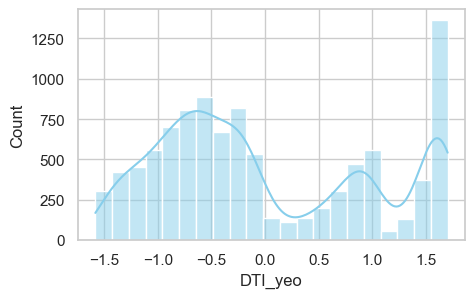

In [102]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
month_transformed = pt.fit_transform(df[["DTI"]])
df["DTI_yeo"] = month_transformed.flatten()
sns.histplot(data=df, x="DTI_yeo", kde=True, color="skyblue")

<Axes: xlabel='DTI_boxcox', ylabel='Count'>

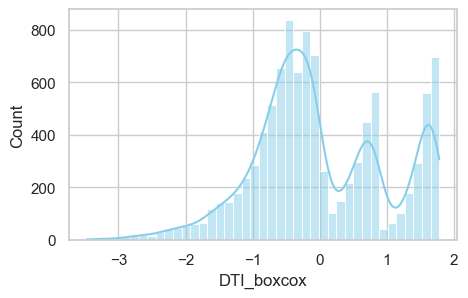

In [103]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method="box-cox")
month_transformed = pt.fit_transform(df[["DTI"]])
df["DTI_boxcox"] = month_transformed.flatten()
sns.histplot(data=df, x="DTI_boxcox", kde=True, color="skyblue")

In [104]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
std_scale = StandardScaler()
m_scale = MinMaxScaler()

In [105]:
m_scale.fit_transform(df[["DTI"]]).flatten()
df["DTI_scale"] = std_scale.fit_transform(df[["DTI"]]).flatten()

<Axes: xlabel='DTI_scale', ylabel='Count'>

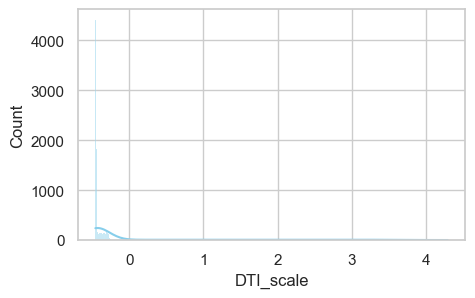

In [106]:
sns.histplot(data=df, x="DTI_scale", kde=True, color="skyblue")

<Axes: xlabel='DTI_scale_yeo', ylabel='Count'>

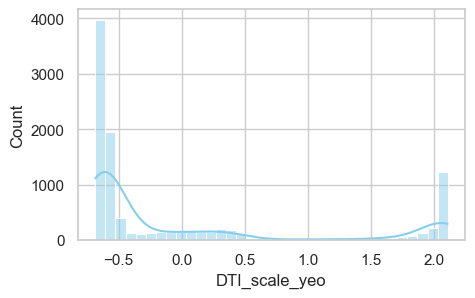

In [107]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
month_transformed = pt.fit_transform(df[["DTI_scale"]])
df["DTI_scale_yeo"] = month_transformed.flatten()
sns.histplot(data=df, x="DTI_scale_yeo", kde=True, color="skyblue")

<Axes: xlabel='Age_in_years', ylabel='Count'>

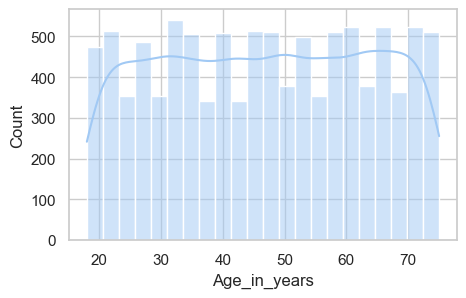

In [108]:
sns.histplot(data=df, x = "Age_in_years", kde=True)

<Axes: xlabel='Age_in_years_scale', ylabel='Count'>

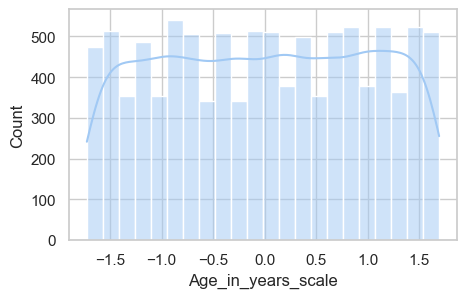

In [109]:
m_scale.fit_transform(df[["Age_in_years"]]).flatten()
df["Age_in_years_scale"] = std_scale.fit_transform(df[["Age_in_years"]]).flatten()
sns.histplot(data=df, x = "Age_in_years_scale", kde=True)

<Axes: xlabel='Age_in_years_log', ylabel='Count'>

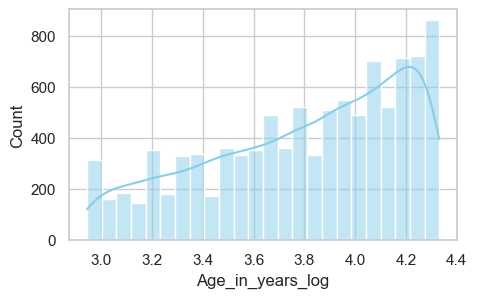

In [110]:
from sklearn.preprocessing import FunctionTransformer
ft = FunctionTransformer(np.log1p)
month_transformed = ft.transform(df[["Age_in_years"]])
df["Age_in_years_log"] = month_transformed
sns.histplot(data=df, x="Age_in_years_log", kde=True, color="skyblue")

<Axes: xlabel='Age_in_years_x2', ylabel='Count'>

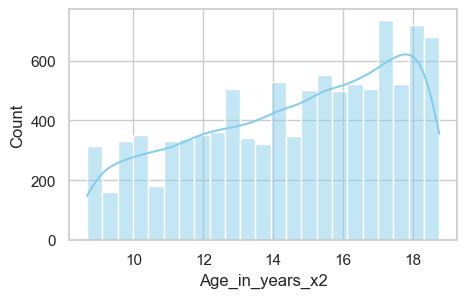

In [111]:
from sklearn.preprocessing import FunctionTransformer
ft = FunctionTransformer(lambda x: x**2)
month_transformed = ft.transform(df[["Age_in_years_log"]])
df["Age_in_years_x2"] = month_transformed
sns.histplot(data=df, x="Age_in_years_x2", kde=True, color="skyblue")

In [208]:
new_df = pd.read_csv("pakistan_credit_dataset_correlated.csv")

In [210]:
new_df.sample(5)

,Client_ID,Duration_in_month,Credit_amount_PKR,Installment_rate_percent_income,Present_residence_since,Age_in_years,Number_of_existing_credits_at_this_bank,Income_PKR,Credit_risk
351,352,24,3370590,4,2,29,2,577042,BAD
146,147,11,1086880,3,2,31,2,251565,GOOD
643,644,6,440123,1,3,55,2,219622,GOOD
913,914,21,3591220,4,5,39,1,589294,BAD
253,254,10,2020794,3,2,39,1,523895,GOOD


In [214]:
new_df.drop(columns=["Client_ID"], inplace=True)

In [216]:
new_df.describe().round(2)

,Duration_in_month,Credit_amount_PKR,Installment_rate_percent_income,Present_residence_since,Age_in_years,Number_of_existing_credits_at_this_bank,Income_PKR
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,11.20,1621389.46,2.69,2.94,41.45,1.97,402338.30
std,5.33,720259.28,1.01,1.40,12.05,0.82,117444.26
min,6.00,95204.00,1.00,1.00,18.00,1.00,30000.00
25%,6.00,1068614.50,2.00,2.00,33.00,1.00,322288.75
50%,10.00,1517846.00,3.00,3.00,41.00,2.00,403035.50
75%,15.00,2108586.00,4.00,4.00,50.00,3.00,477752.75
max,37.00,4096951.00,4.00,5.00,70.00,3.00,862327.00


In [218]:
num_cols = new_df.select_dtypes(include=np.number).columns

In [220]:
corr = new_df[num_cols].corr()

In [222]:
num_cols

Index(['Duration_in_month', 'Credit_amount_PKR',
       'Installment_rate_percent_income', 'Present_residence_since',
       'Age_in_years', 'Number_of_existing_credits_at_this_bank',
       'Income_PKR'],
      dtype='object')

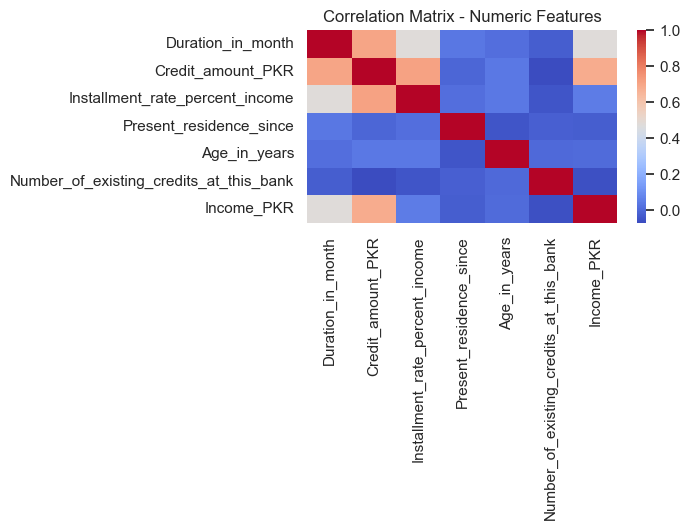

In [224]:
plt.figure(figsize=(5,2.5))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix - Numeric Features")
plt.show()

<Axes: xlabel='Present_residence_since', ylabel='Count'>

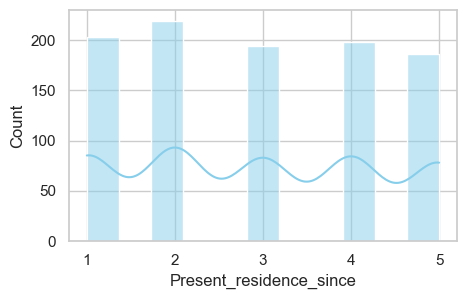

In [236]:
sns.histplot(data=new_df, x="Present_residence_since", kde=True, color="skyblue")

<Axes: xlabel='Credit_amount_PKR', ylabel='Credit_risk'>

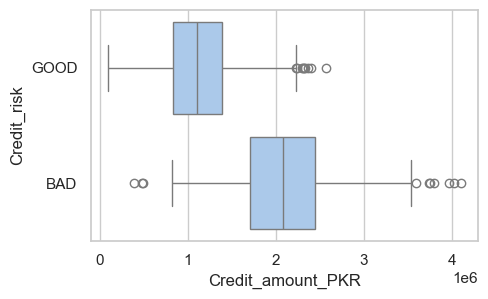

In [230]:
sns.boxplot(data=new_df, x="Credit_amount_PKR", y="Credit_risk")

<Axes: xlabel='Duration_in_month_log', ylabel='Count'>

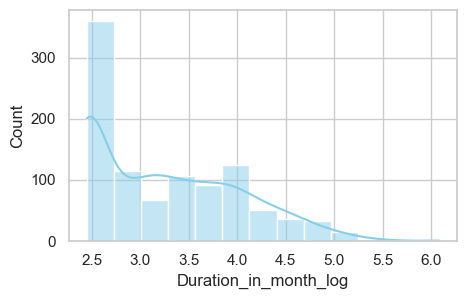

In [258]:
from sklearn.preprocessing import FunctionTransformer
ft = FunctionTransformer(lambda x: x**0.5)
month_transformed = ft.transform(new_df[["Duration_in_month"]])
new_df["Duration_in_month_log"] = month_transformed
sns.histplot(data=new_df, x="Duration_in_month_log", kde=True, color="skyblue")

In [188]:
df.describe().round(2)

,Duration_in_month,Credit_amount,Installment_rate_percent_income,Present_residence_since,Age_in_years,Number_of_existing_credits_at_this_bank,Annual Income (PKR),Number_of_people_liable_for_maintenance,Annual Income (PKR)_boxcox,Annual Income (PKR)_yeo,Duration_in_month_yeojohnson,Annual Income (PKR)_log,DTI,DTI_log,DTI_yeo,DTI_boxcox,DTI_scale,DTI_scale_yeo,Age_in_years_scale,Age_in_years_log,Age_in_years_x2,Income_PKR_log
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,1000.00,10000.00,1000.00
mean,38.11,10170476.80,2.51,2.50,46.78,2.51,5844892.49,1.5,-0.00,-0.00,0.00,14.41,60.73,2.00,0.00,-0.00,0.00,-0.00,0.00,3.74,14.57,608.11
std,19.94,5655360.89,1.12,1.12,16.68,1.12,5236164.14,0.5,1.00,1.00,1.00,2.19,133.51,1.91,1.00,1.00,1.00,1.00,1.00,0.36,2.87,190.96
min,4.00,250000.00,1.00,1.00,18.00,1.00,29456.00,1.0,-1.57,-1.57,-1.93,10.29,0.02,0.02,-1.58,-3.47,-0.45,-0.68,-1.73,2.94,8.67,176.10
25%,21.00,5322500.00,2.00,1.00,32.00,2.00,774202.25,1.0,-0.76,-0.76,-0.81,13.56,0.88,0.63,-0.79,-0.63,-0.45,-0.63,-0.89,3.47,12.23,462.52
50%,38.00,10217500.00,3.00,2.00,47.00,3.00,6103417.00,1.0,0.43,0.43,0.07,15.62,2.05,1.11,-0.29,-0.19,-0.44,-0.57,0.01,3.81,14.99,638.45
75%,56.00,15016250.00,4.00,4.00,61.00,4.00,8158131.75,2.0,0.67,0.67,0.90,15.91,18.62,2.98,0.92,0.75,-0.32,0.24,0.85,4.06,17.03,776.45
max,72.00,20000000.00,4.00,4.00,75.00,4.00,16498158.00,2.0,1.36,1.36,1.57,16.62,633.16,6.45,1.70,1.78,4.29,2.11,1.69,4.25,18.76,893.76


<Axes: xlabel='Age_in_years', ylabel='Count'>

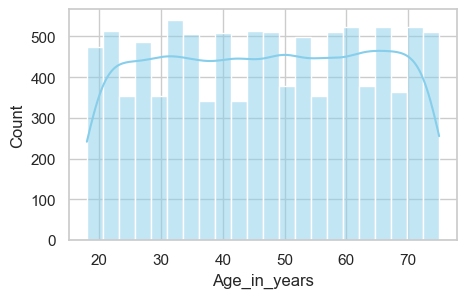

In [190]:
sns.histplot(data=df, x="Age_in_years", kde=True, color="skyblue")

<Axes: xlabel='Annual Income (PKR)', ylabel='Credit_Risk'>

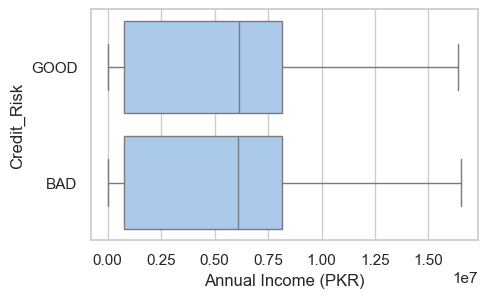

In [268]:
sns.boxplot(data=df, x="Annual Income (PKR)", y="Credit_Risk")